In [1]:
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Copy the zip file from My Drive to the local Colab storage
# Note: Copying it locally first makes reading images during training MUCH faster!
!cp "/content/drive/MyDrive/anime_faces.zip" "/content/anime_faces.zip"

# 3. Unzip the dataset into a new folder
# The '-q' flag keeps it quiet so it doesn't crash your browser by printing thousands of file names
!unzip -q "/content/anime_faces.zip" -d "/content/"

print("Dataset copied and unzipped successfully!")

Mounted at /content/drive
Dataset copied and unzipped successfully!


In [2]:
# installation cell
!pip install ipywidgets piq tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.6 MB/s eta 0:00:00


In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from piq import ssim as ssim_func
import os
import shutil
from tqdm import tqdm
from torch.utils.data import TensorDataset

In [17]:
# HYPERPARAMETERS
total_epochs = 30
warmup_epochs = 10
beta_initial = 0.0
beta_target = 3.0
latent_dim = 16
learning_rate = 1e-4
batch_size = 64

In [18]:
# 1. Basic transformation
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

# 2. Point to your image folder
dataset = datasets.ImageFolder(root='./anime_faces/train', transform=transform)
val_dataset = datasets.ImageFolder(root='./anime_faces/val',transform=transform)
# 3. Create the DataLoader
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset,batch_size=batch_size,num_workers=os.cpu_count())

# 4. Test it: Pull one batch of images
images, labels = next(iter(train_loader))

print(f"Batch shape: {images.shape}")

Batch shape: torch.Size([64, 3, 48, 48])


In [19]:
# def cache_dataset(dataset):
#     """Load all images into RAM as a single tensor batch."""
#     loader = DataLoader(dataset, batch_size=256, num_workers=os.cpu_count(), pin_memory=False)
#     images_list, labels_list = [], []
#     for imgs, lbls in tqdm(loader, desc="Caching to RAM"):
#         images_list.append(imgs)
#         labels_list.append(lbls)
#     return TensorDataset(torch.cat(images_list), torch.cat(labels_list))

# print("Caching train set...")
# train_cached = cache_dataset(dataset)
# print("Caching val set...")
# val_cached   = cache_dataset(val_dataset)

# # Replace the loaders with ram based loaders
# train_loader = DataLoader(train_cached, batch_size=batch_size, shuffle=True,  num_workers=0)
# val_loader   = DataLoader(val_cached,   batch_size=batch_size, shuffle=False, num_workers=0)
# print(f"Done. Train: {len(train_cached)} | Val: {len(val_cached)}")

In [20]:
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(BetaVAE, self).__init__()

        # Encoder: 3x48x48 -> Latent Space
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), # 24x24
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 12x12
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 6x6
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 3x3
            nn.ReLU(),
            nn.Flatten()
        )

        # Latent vectors (mu and log_var)
        # 256 * 3 * 3 = 2304
        self.fc_mu = nn.Linear(2304, latent_dim)
        self.fc_logvar = nn.Linear(2304, latent_dim)

        # Decoder: Latent Space -> 3x48x48
        self.decoder_input = nn.Linear(latent_dim, 2304)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 3, 3)),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 6x6
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 12x12
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 24x24
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),  # 48x48
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """The Reparameterization Trick: z = mu + std * epsilon"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.decoder_input(z)), mu, logvar

# --- The Beta-VAE Loss Function ---
def loss_function(recon_x, x, mu, logvar, beta=4.0):
    # Structural Loss (SSIM)
    ssim_val = ssim_func(recon_x, x, data_range=1.0, reduction='mean')
    reconstruction_loss = (1 - ssim_val) * (48*48*3)

    # 2. KL Divergence
    kld_element = 1 + logvar - mu.pow(2) - logvar.exp()
    kld_loss = -0.5 * torch.mean(torch.sum(kld_element, dim=1))

    # Total loss
    total_loss = reconstruction_loss + (beta * kld_loss)
    return total_loss, reconstruction_loss, kld_loss

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)
model = BetaVAE(latent_dim=latent_dim).to(device)

cuda


In [22]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [23]:
def train_epoch(model, dataloader, optimizer, device, beta_weight=4.0):
    model.train()

    # Sum of losses
    running_loss = 0.0
    running_rec = 0.0
    running_kld = 0.0

    progress_bar = tqdm(dataloader, total=len(dataloader), desc="Training", leave=False)

    for images, _ in progress_bar:
        images = images.to(device)
        batch_size = images.size(0)

        # Forward pass
        recon_batch, mu, logvar = model(images)
        batch_loss, batch_rec, batch_kld = loss_function(recon_batch, images, mu, logvar, beta=beta_weight)

        # Backward pass
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        # Accumulate sums (mean loss * batch_size = sum loss)
        running_loss += batch_loss.item() * batch_size
        running_rec += batch_rec.item() * batch_size
        running_kld += batch_kld.item() * batch_size

        # Display the current batch mean loss in the progress bar
        progress_bar.set_postfix({
            "Loss": f"{batch_loss.item():.4f}",
            "Rec": f"{batch_rec.item():.4f}",
            "KLD": f"{batch_kld.item():.4f}"
        })

    # Calculate true epoch averages
    dataset_size = len(dataloader.dataset)
    epoch_loss = running_loss / dataset_size
    epoch_rec = running_rec / dataset_size
    epoch_kld = running_kld / dataset_size

    return epoch_loss, epoch_rec, epoch_kld

In [24]:
def save_checkpoint(state_dict, is_best, folder="./checkpoints", filename="checkpoint.pth"):
    os.makedirs(folder, exist_ok=True)
    filepath = os.path.join(folder, filename)

    # Save the latest epoch
    torch.save(state_dict, filepath)

    # If it's the best so far, overwrite the best model file
    if is_best:
        best_filepath = os.path.join(folder, "model_best.pth")
        shutil.copyfile(filepath, best_filepath)
        # Updated key here to match the new payload!
        print(f"--> ✨ New best model saved! Val Loss: {state_dict['best_val_loss']:.4f}")

In [25]:
# --- Validation Function ---
@torch.no_grad()
def validate_epoch(model, dataloader, device, beta_weight=4.0):
    """Runs a single pass over the validation set without tracking gradients."""
    model.eval()

    running_loss = 0.0
    running_rec = 0.0
    running_kld = 0.0

    for images, _ in dataloader:
        images = images.to(device)
        batch_size = images.size(0)

        # Forward pass only
        recon_batch, mu, logvar = model(images)
        batch_loss, batch_rec, batch_kld = loss_function(recon_batch, images, mu, logvar, beta=beta_weight)

        # Accumulate sums
        running_loss += batch_loss.item() * batch_size
        running_rec += batch_rec.item() * batch_size
        running_kld += batch_kld.item() * batch_size

    dataset_size = len(dataloader.dataset)
    return running_loss / dataset_size, running_rec / dataset_size, running_kld / dataset_size

In [26]:
checkpoint_path = "./checkpoints/checkpointv1.pth"

# --- Setup & Nomenclature ---
best_val_loss = float('inf')

start_epoch = 1

# Clean history tracking, now actually tracking validation
history = {
    'train_loss': [], 'train_rec': [], 'train_kld': [],
    'val_loss': [], 'val_rec': [], 'val_kld': [],
    'learning_rate': []
}

# Check if the file actually exists
if os.path.exists(checkpoint_path):
    print(f"Found checkpoint at {checkpoint_path}. Loading...")

    # Load the model
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Restore the model and optimizer memory
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    # Restore our trackers
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    history = checkpoint['history']

    print(f"Resuming training from Epoch {start_epoch}")
else:
    print("No checkpoint found. Starting training from scratch.")

No checkpoint found. Starting training from scratch.


In [27]:
def cache_dataset_vram(dataset, device):
    """Load all images directly into VRAM (GPU memory) as a single tensor batch."""

    # pin_memory=True speeds up the initial transfer from CPU to GPU
    loader = DataLoader(dataset, batch_size=256, num_workers=os.cpu_count(), pin_memory=True)
    images_list, labels_list = [], []

    for imgs, lbls in tqdm(loader, desc=f"Caching to VRAM ({device})"):
        # Move data to the GPU immediately
        # non_blocking=True allows asynchronous data transfers, speeding up the process
        images_list.append(imgs.to(device, non_blocking=True))
        labels_list.append(lbls.to(device, non_blocking=True))

    return TensorDataset(torch.cat(images_list), torch.cat(labels_list))

# --- How to use it ---
# # Make sure 'device' is defined before calling this!
print("Caching train set to VRAM...")
train_cached_vram = cache_dataset_vram(dataset, device)
print("Caching val set to VRAM...")
val_cached_vram   = cache_dataset_vram(val_dataset, device)

# # Replace the loaders with VRAM-based loaders
# # IMPORTANT: num_workers MUST be 0 here because multiprocessing cannot handle GPU tensors
train_loader = DataLoader(train_cached_vram, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_cached_vram,   batch_size=batch_size, shuffle=False, num_workers=0)
print(f"Done. Train: {len(train_cached_vram)} | Val: {len(val_cached_vram)}")

Caching train set to VRAM...


Caching to VRAM (cuda): 100%|██████████| 245/245 [00:33<00:00,  7.32it/s]


Caching val set to VRAM...


Caching to VRAM (cuda): 100%|██████████| 4/4 [00:00<00:00,  4.23it/s]

Done. Train: 62541 | Val: 1024


In [28]:
print(f"Starting training on device: {device}")

for epoch in range(start_epoch, total_epochs + 1):
    # Step function for Beta Warmup
    current_beta = min(beta_target, beta_initial + (beta_target / warmup_epochs) * (epoch - 1))
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch}/{total_epochs}] | Beta: {current_beta:.1f} | LR: {current_lr}")

    # 1. Run one training epoch
    train_loss, train_rec, train_kld = train_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device,
        beta_weight=current_beta
    )

    # 2. Run one validation epoch
    val_loss, val_rec, val_kld = validate_epoch(
        model=model,
        dataloader=val_loader,
        device=device,
        beta_weight=current_beta
    )

    # 3. Record history
    history['train_loss'].append(train_loss)
    history['train_rec'].append(train_rec)
    history['train_kld'].append(train_kld)

    history['val_loss'].append(val_loss)
    history['val_rec'].append(val_rec)
    history['val_kld'].append(val_kld)

    history['learning_rate'].append(current_lr)

    # 4. Print logs
    print(f"  Train -> Loss: {train_loss:.4f} (Rec: {train_rec:.4f}, KLD: {train_kld:.4f})")
    print(f"  Val   -> Loss: {val_loss:.4f} (Rec: {val_rec:.4f}, KLD: {val_kld:.4f})")

    # 5. Check if this is the best model (Evaluating based on VALIDATION loss)
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss

    # 6. Save Checkpoint payload
    checkpoint_payload = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
        'history': history,
    }
    save_checkpoint(checkpoint_payload, is_best)

    scheduler.step(val_loss)

Starting training on device: cuda
Epoch [1/30] | Beta: 0.0 | LR: 0.0001


  Train -> Loss: 4666.8611 (Rec: 4666.8611, KLD: 1171.1243)
  Val   -> Loss: 4243.9698 (Rec: 4243.9698, KLD: 628.7785)
--> ✨ New best model saved! Val Loss: 4243.9698
Epoch [2/30] | Beta: 0.3 | LR: 0.0001


  Train -> Loss: 3857.7660 (Rec: 3827.7986, KLD: 99.8914)
  Val   -> Loss: 3828.5662 (Rec: 3809.0720, KLD: 64.9807)
--> ✨ New best model saved! Val Loss: 3828.5662
Epoch [3/30] | Beta: 0.6 | LR: 0.0001


  Train -> Loss: 3630.6139 (Rec: 3598.4968, KLD: 53.5285)
  Val   -> Loss: 3747.0998 (Rec: 3717.2184, KLD: 49.8024)
--> ✨ New best model saved! Val Loss: 3747.0998
Epoch [4/30] | Beta: 0.9 | LR: 0.0001


  Train -> Loss: 3566.4765 (Rec: 3525.2229, KLD: 45.8373)
  Val   -> Loss: 3707.3125 (Rec: 3665.4837, KLD: 46.4764)
--> ✨ New best model saved! Val Loss: 3707.3125
Epoch [5/30] | Beta: 1.2 | LR: 0.0001


...

  Train -> Loss: 3310.0509 (Rec: 3195.9383, KLD: 38.0375)
  Val   -> Loss: 3536.3282 (Rec: 3425.0096, KLD: 37.1062)
Epoch [27/30] | Beta: 3.0 | LR: 0.0001


  Train -> Loss: 3304.8167 (Rec: 3190.3848, KLD: 38.1440)
  Val   -> Loss: 3533.0086 (Rec: 3421.8513, KLD: 37.0524)
--> ✨ New best model saved! Val Loss: 3533.0086
Epoch [28/30] | Beta: 3.0 | LR: 0.0001


  Train -> Loss: 3299.8638 (Rec: 3185.0896, KLD: 38.2580)
  Val   -> Loss: 3529.4762 (Rec: 3415.1744, KLD: 38.1006)
--> ✨ New best model saved! Val Loss: 3529.4762
Epoch [29/30] | Beta: 3.0 | LR: 0.0001


  Train -> Loss: 3294.5413 (Rec: 3179.7093, KLD: 38.2773)
  Val   -> Loss: 3526.0640 (Rec: 3413.9783, KLD: 37.3619)
--> ✨ New best model saved! Val Loss: 3526.0640
Epoch [30/30] | Beta: 3.0 | LR: 0.0001


  Train -> Loss: 3289.8038 (Rec: 3174.6776, KLD: 38.3754)
  Val   -> Loss: 3523.0056 (Rec: 3409.6118, KLD: 37.7979)
--> ✨ New best model saved! Val Loss: 3523.0056


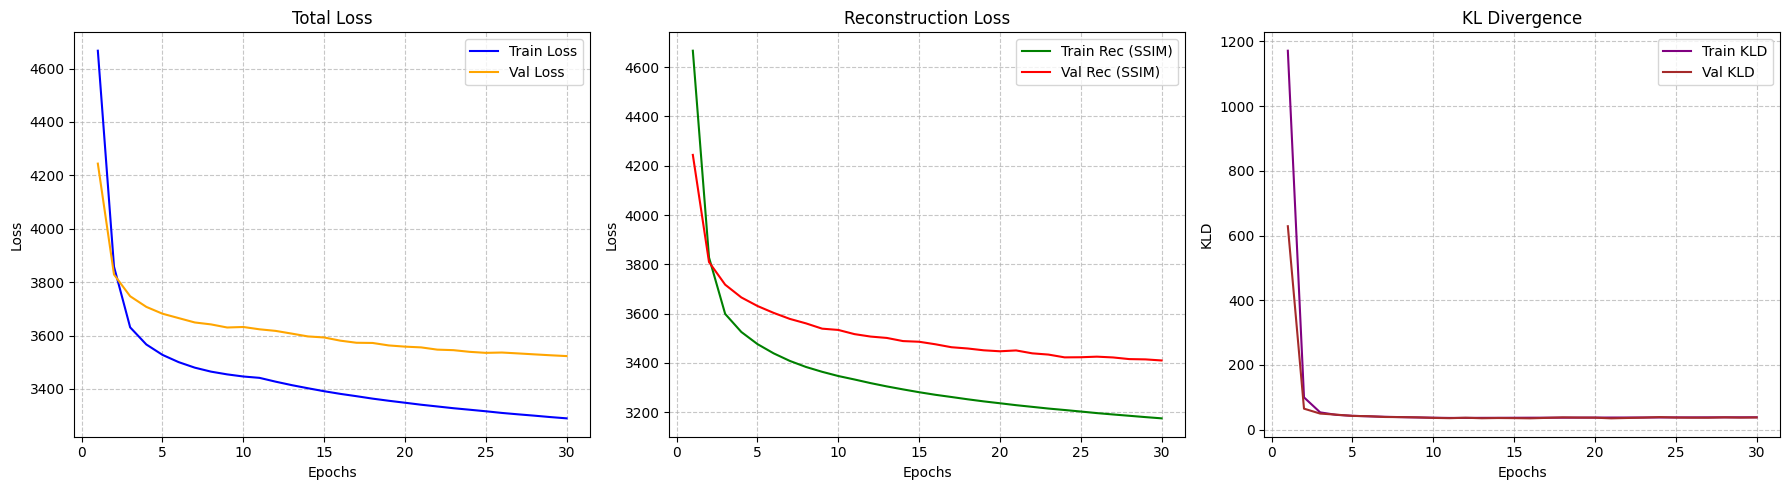

In [29]:
def plot_training_curves(history):
    # Determine the number of epochs trained so far
    epochs = range(1, len(history['train_loss']) + 1)

    # Create a 1x3 grid for our plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- 1. Total Loss ---
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss', color='orange')
    axes[0].set_title('Total Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # --- 2. Reconstruction Loss ---
    axes[1].plot(epochs, history['train_rec'], label='Train Rec (SSIM)', color='green')
    axes[1].plot(epochs, history['val_rec'], label='Val Rec (SSIM)', color='red')
    axes[1].set_title('Reconstruction Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # --- 3. KL Divergence ---
    axes[2].plot(epochs, history['train_kld'], label='Train KLD', color='purple')
    axes[2].plot(epochs, history['val_kld'], label='Val KLD', color='brown')
    axes[2].set_title('KL Divergence')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('KLD')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Call the function to display the plots
plot_training_curves(history)